In [ ]:
#!pip install geopandas

In [2]:
# Had to read population data through an excel workbook
import geopandas
import pandas
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import os
from time import time
import numpy as np
from pprint import pprint
from shapely.geometry import box

state_name = 'New Mexico'
state_abbrev = 'nm'
state_num = 35
nDistricts = 3
the_epsg = 6528  # https://epsg.io/6528

# pop_total_denominator = 330759736
# totalDistricts = 435
# target = pop_total_denominator / totalDistricts
state_total_pop = 2117522
target = state_total_pop / nDistricts

shapefile_dir = '/home/idies/workspace/21cc/Data/Census/Shapefiles/TIGER/'
new_districts_dir = '/home/idies/workspace/21cc/raddick/ungerrymandering/new-districts/'
pl94_dir = '/home/idies/workspace/21cc/Data/Census/PL 94-171 2020/{0:}/'.format(state_abbrev)

district_color_cycle = ['black', 'red', 'green', 'orange', 'cyan', 'yellow', 'pink', 'gray', 'lime', 'navajowhite', 'cornflowerblue', 'darkseagreen', 'thistle', 'tomato', 'silver', 'blueviolet', 'olive', 'peru', 'dodgerblue']
district_color_cycle += district_color_cycle
district_color_cycle += district_color_cycle
the_legend_size = 12
the_annotation_size = 8


print('ok')


ok


# Get population data by tract

In [3]:
#df = pandas.read_csv(
s = time()    
geofiles = [pl94_dir+x for x in os.listdir(pl94_dir) if (('geo' in x) and (x[-3:] == '.pl'))]
    #geofiles.append([x for x in geofiles if x[0:2] == this_focus_state.lower()])
geo_df = pandas.DataFrame()

for thisfile in geofiles:
    print('\treading {0:}...'.format(thisfile))
    geo_df_i = pandas.read_csv(thisfile, sep='|', header=None, low_memory=False, encoding='ISO-8859-1')#, encoding='utf-8')
    geo_df = pandas.concat((geo_df, geo_df_i), axis=0)
    
print('renaming columns...')
column_names = []
column_names += ['FILEID', 'STUSAB', 'SUMLEV', 'GEOVAR', 'GEOCOMP', 'CHARITER', 'CIFSN', 'LOGRECNO', 'GEOID']
column_names += ['GEOCODE', 'REGION', 'DIVISION', 'STATE', 'STATENS', 'COUNTY', 'COUNTYCC', 'COUNTYNS']
column_names += ['COUSUB', 'COUSUBCC', 'COUSUBNS']
column_names += ['SUBMCD', 'SUBMDCC', 'SUBMCDNS', 'ESTATE', 'ESTATECC', 'ESTATENS']
column_names += ['CONCIT', 'CONCITCC', 'CONCITNS', 'PLACE','PLACECC', 'PLACENS']
column_names += ['TRACT', 'BLKGRP', 'BLOCK']
column_names += ['AIANHH', 'AIANHHLI', 'AIANHHFP', 'AIANHHCC', 'AIANHHNS', 'AITS', 'AITSFP', 'AITSCC', 'AITSNS']
column_names += ['TTRACT', 'TBLKGRP', 'ANRC', 'ANRCCC', 'ARNCNS']
column_names += ['CBSA', 'MEMI', 'CSA', 'METDIV']
column_names += ['NECTA', 'NMEMI', 'CNECTA', 'NECTADIV']
column_names += ['CBSAPCI', 'NECTAPCI', 'UA', 'UATYPE', 'UR']
column_names += ['CD116', 'CD118', 'CD119', 'CD120', 'CD121']
column_names += ['SLDU18', 'SLDU22', 'SLDU24', 'SLDU26', 'SLDU28']
column_names += ['SLDL18', 'SLDL22', 'SLDL24', 'SLDL26', 'SLDL28']
column_names += ['VTD', 'VTDI', 'ZCTA', 'SDELM', 'SDSEC', 'SDUNI', 'PUMA']
column_names += ['AREALAND', 'AREAWATER', 'BASENAME', 'NAME', 'FUNCSTAT', 'GCUNI']
column_names += ['POP100', 'HU100']
column_names += ['INTPTLAT', 'INTPTLON', 'LSADC', 'PARTFLAG', 'UGA']

geo_df.columns = column_names

print('\tTotal columns: {0:.0f}'.format(len(geo_df.columns)))
print('\tNamed columns: {0:.0f}'.format(len(column_names)))

geo_df = geo_df.set_index('GEOID')
tract_pop_df = geo_df[geo_df['SUMLEV'] == 140]
e = time()

print('Got populations of {0:,.0f} census tracts in {1:,.0f} seconds!'.format(len(tract_pop_df), e-s))


	reading /home/idies/workspace/21cc/Data/Census/PL 94-171 2020/nm/nmgeo2020.pl...
renaming columns...
	Total columns: 97
	Named columns: 97
Got populations of 612 census tracts in 5 seconds!


# Get shapefiles

In [4]:
print('getting new districts...')
new_districts_df = pandas.read_csv(new_districts_dir+'new-districts-1-to-7.csv')

print('getting tracts...')
tracts_gdf = geopandas.read_file(shapefile_dir+'2020/TRACT/tl_2020_{0:02d}_tract.shp'.format(state_num))

tracts_gdf.loc[:, 'GEOID'] = tracts_gdf['GEOID'].apply(lambda x: '1400000US'+x)
tracts_gdf = tracts_gdf[tracts_gdf['GEOID'].apply(lambda x: '1400000US{0:02d}'.format(state_num) in x)]
tracts_gdf = tracts_gdf.set_index('GEOID')

new_districts_df = new_districts_df[new_districts_df['GEOID'].apply(lambda x: '1400000US{0:02d}'.format(state_num) in x)]
new_districts_df = new_districts_df.set_index('GEOID')

tracts_gdf = tracts_gdf.join(new_districts_df)
tracts_gdf = tracts_gdf[[x for x in tracts_gdf.columns if x != 'geometry']+['geometry']]

print('joining population data...')
tracts_gdf = tracts_gdf.join(tract_pop_df['POP100'])

print('getting original districts...')
cd119_gdf = geopandas.read_file(shapefile_dir+'2025/CD/tl_2025_{0:02d}_cd119.shp'.format(state_num))
cd119_gdf = cd119_gdf.assign(CD119 = pandas.to_numeric(cd119_gdf['CD119FP'], errors='coerce', downcast='integer'))

print('getting places...')
place_gdf = geopandas.read_file(shapefile_dir+'2025/PLACE/tl_2025_{0:02d}_place.shp'.format(state_num))
place_gdf = place_gdf.set_index('GEOIDFQ')

# print('getting water...')
# s = time()
# thefilelist = [shapefile_dir+'/2025/AREAWATER/{0:}/'.format(state_abbrev)+x for x in os.listdir(shapefile_dir+'/2025/AREAWATER/{0:}/'.format(state_abbrev)) if x[-4:] == '.shp']
# water_gdf = geopandas.GeoDataFrame()
# for i in range(0,len(thefilelist)):
#     if ((np.mod(i, 10) == 0) | (i == len(thefilelist))):
#         print('Reading areawater file {0:,.0f} of {1:,.0f}...'.format(i, len(thefilelist)))
#     ggdf = geopandas.read_file(thefilelist[i])
#     water_gdf = pandas.concat((water_gdf, ggdf), axis=0)
# water_gdf.loc[:, 'HYDROID'] = water_gdf['HYDROID'].apply(lambda x: x.ljust(14, '0'))
# water_gdf = water_gdf.set_index('HYDROID')
# water_gdf.loc[:, 'INTPTLON'] = pandas.to_numeric(water_gdf['INTPTLON'])
# water_gdf.loc[:, 'INTPTLAT'] = pandas.to_numeric(water_gdf['INTPTLAT'])
# water_gdf = water_gdf.sort_values(by='AWATER', ascending=False)
# #water_gdf = water_gdf.to_crs(tracts_gdf.crs)

print('changing crs...')
for thisdf in [tracts_gdf, cd119_gdf, place_gdf]:#, water_gdf]:
    thisdf = thisdf.to_crs(epsg=the_epsg)
e = time()
#print('Read {0:,.0f} bodies of areawater in {1:} in {2:,.1f} seconds!'.format(len(water_gdf), state_name, e-s))    

print('Got districts for {0:,.0f} census tracts'.format(len(tracts_gdf)))


getting new districts...
getting tracts...
joining population data...
getting original districts...
getting places...
changing crs...
Got districts for 612 census tracts


In [ ]:
# # Fix water
# show_water_gdf = geopandas.GeoDataFrame()
# excluded_gdf = geopandas.GeoDataFrame()

# include_signs = []
# include_signs += ['Pacific Ocean']
# include_signs += ['Hanalei Bay','Nawiliwili Bay','Hilo Bay','Kealakekua Bay','Kiholo Bay','Puhi Bay','Anaehoomalu Bay','Kuhio Bay','Honokohau Bay','Old Kona Bay','Reeds Bay','Kaalualu','Kailua Bay','Honuapo Bay','Kuamoo Bay','Honokaope Bay','Onomea Bay'] # Kauai and Big Island
# include_signs += ['Alenuihaha Chnnl','Alalakeiki Chnnl','Auau Chnnl','Kealaikahiki Chnnl','Kalohi Chnnl','Long Hbr','Waikahalulu Bay','Maalea Bay','Kanapou Bay','Kalaupapa Hbr','Kaunakakai Hbr','Halawa Bay','Kahului Hbr','Poelua Bay','Ahihi Bay','Mamalu Bay','La Perouse Bay','Uaoa Bay'] # Maui and friends
# include_signs += ['Mamala Bay','Kaneohe Bay','Waimanalo Bay','East Loch Pearl Hbr','Keehi Lagoon','West Loch Pearl Hbr','Pearl Harbor Entrance','Maunaloa Bay','West Loch Pearl Hbr','Honolulu Hbr','Southeast Loch Pearl Hbr','Kalaeloa Hbr','Kahana Bay','Waialua Bay','Laie Bay','Hanauma Bay','Kaiaka Bay']

# show_water_gdf = pandas.concat((show_water_gdf, 
#                               water_gdf[water_gdf['FULLNAME'].apply(
#                                   lambda x: x in include_signs
#                               )]))
# unnamed_ocean_areas = []
# unnamed_ocean_areas += ['11050976825800'] # Oahu
# show_water_gdf = pandas.concat((show_water_gdf, water_gdf[water_gdf.index.isin(unnamed_ocean_areas)]))

# excluded_gdf = pandas.concat((excluded_gdf, water_gdf[~water_gdf.index.isin(show_water_gdf.index.tolist())]))

# show_water_gdf = show_water_gdf.sort_values(by='AWATER', ascending=False)
# show_water_gdf = show_water_gdf.to_crs(water_gdf.crs)

# excluded_gdf = excluded_gdf.sort_values(by='AWATER', ascending=False)
# excluded_gdf = excluded_gdf.to_crs(water_gdf.crs)

# print('ok')

In [ ]:
# xlim = [-161,-154.5] 
# ylim = [18.5,22.5]

# show_names = False
# nNames = 9

# print('plotting...')
# fig, ax = plt.subplots(1,1)
# ax.set_aspect('equal')

# tracts_gdf.plot(ax=ax, color='none', edgecolor='gray')

# # show_water_gdf.plot(ax=ax, color='blue')
# # excluded_gdf.plot(ax=ax, color='pink')

# show_water_gdf[
#     ((show_water_gdf['INTPTLON'].apply(lambda x: x >= xlim[0])) & (show_water_gdf['INTPTLON'].apply(lambda x: x <= xlim[1])))
#     & (show_water_gdf['INTPTLAT'].apply(lambda y: y >= ylim[0])) & (show_water_gdf['INTPTLAT'].apply(lambda y: y <= ylim[1]))
# ].plot(ax=ax, color='blue')

# excluded_gdf[
#     ((excluded_gdf['INTPTLON'].apply(lambda x: x >= xlim[0])) & (excluded_gdf['INTPTLON'].apply(lambda x: x <= xlim[1])))
#     & (excluded_gdf['INTPTLAT'].apply(lambda y: y >= ylim[0])) & (excluded_gdf['INTPTLAT'].apply(lambda y: y <= ylim[1]))
# ].plot(ax=ax, color='red')

# ax.set_xlim(xlim)
# ax.set_ylim(ylim)

# if (show_names):
#     for ix, thisrow in excluded_gdf[
#         ((excluded_gdf['INTPTLON'].apply(lambda x: x >= xlim[0])) & (excluded_gdf['INTPTLON'].apply(lambda x: x <= xlim[1])))
#         & (excluded_gdf['INTPTLAT'].apply(lambda y: y >= ylim[0])) & (excluded_gdf['INTPTLAT'].apply(lambda y: y <= ylim[1]))
#     ].head(nNames).sort_values(by='AWATER', ascending=False).iterrows():
#         if (thisrow['FULLNAME'] != None):
#             annotator = thisrow['FULLNAME']
#         else:
#             annotator = ix
#         print(annotator)
#         ax.annotate(annotator, (thisrow['INTPTLON'], thisrow['INTPTLAT']), (thisrow['INTPTLON'], thisrow['INTPTLAT']), 
#                    ha='center', backgroundcolor='white', size=6)

# plt.show()

# # #print('ok')
# # # Main islands: xlim = [-161,-154.5] ; ylim = [18.5,22.5]
# # Kauai/Niihau: xlim = [-160.7,-159.3] ; ylim = [21.5,22.4]
# # Big Island: xlim = [-156.3,-154.6] ; ylim = [18.5,20.5]
# # Maui and friends: xlim = [-157.4,-155.9] ; ylim = [20.4,21.4]
# # Oahu: xlim = [-158.3,-157.625] ; ylim = [21.2,21.75]

setting up insets for Albuquerque...
abq
inset abq...
	districts...
		Plotting District 1...
		Plotting District 2...
		Plotting District 3...


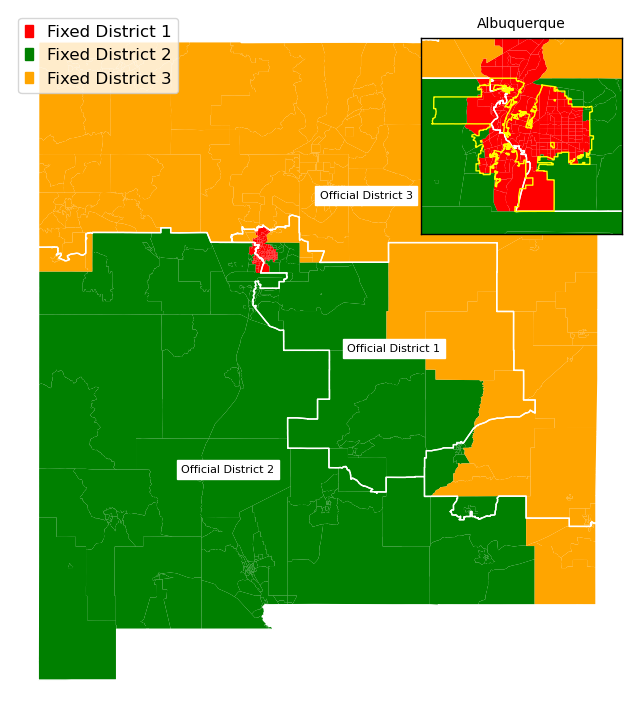

In [28]:
fig, ax = plt.subplots(1,1,figsize=(8,12))
ax.set_aspect('equal')

xlim = [-106.9,-106.4]
ylim = [34.9,35.3]
# Around ABQ: xlim = [-107,-106] ; ylim = [34.75,35.5]




print('setting up insets for Albuquerque...')
insets = {}
    
insets['abq'] = {}
insets['abq']['how'] = 'tracts'   # tracts, districts, counties, or places
insets['abq']['bounds'] = [-106.9,34.9,-106.4,35.3]
insets['abq']['axes_position'] = [.65, .68]
insets['abq']['axes_rel_size'] = .35
insets['abq']['new_districts'] = [1,2,3]
insets['abq']['title'] = 'Albuquerque'
insets['abq']['titlesize'] = 10
insets['abq']['borderwidth'] = 1

for inset_name, inset in insets.items():
    print(inset_name)
    
    if ('bounds' in inset.keys()):
        inset['aspect_ratio'] = (inset['bounds'][2] - inset['bounds'][0]) / (inset['bounds'][3] - inset['bounds'][1])
    else:
        if (inset['how'] == 'tracts'):
            thegeo = unary_union(tracts_gdf.geometry.tolist()).bounds
        elif (inset['how'] == 'districts'):
            thegeo = unary_union(cd_gdf[cd_gdf['CD116'].isin(inset['districts'])].geometry.tolist()).bounds
        elif (inset['how'] == 'counties'):
            thegeo = unary_union(tract_gdf[tract_gdf['COUNTY_NAME'].isin(inset['counties'])].geometry.tolist()).bounds
        elif (inset['how'] == 'places'):
            thegeo = unary_union(place_gdf[place_gdf['NAME'].isin(inset['places'])].geometry.tolist()).bounds
        xlims = [thegeo[0], thegeo[2]]
        ylims = [thegeo[1], thegeo[3]]        
        xspan = xlims[1] - xlims[0]
        yspan = ylims[1] - ylims[0]
        inset['aspect_ratio'] = xspan / yspan
        xlims[0] = xlims[0] - (map_buffer_ratio * xspan)
        ylims[0] = ylims[0] - (map_buffer_ratio * yspan)
        xlims[1] = xlims[1] + (map_buffer_ratio * xspan)
        ylims[1] = ylims[1] + (map_buffer_ratio * yspan)    
        inset['bounds'] = [xlims[0], ylims[0], xlims[1], ylims[1]]
        #print(inset['bounds'])
    
    inset['box_gdf'] = geopandas.GeoDataFrame(data=[[
        box(
            inset['bounds'][0], 
            inset['bounds'][1], 
            inset['bounds'][2], 
            inset['bounds'][3]
        )]], columns=['geometry'], crs=cd119_gdf.crs, geometry='geometry')    
    inset['axes_size'] = [inset['axes_rel_size'], inset['axes_rel_size'] / inset['aspect_ratio']]
#    print(inset['axes_size'])



for i in range (1, nDistricts+1):
    tracts_gdf[tracts_gdf['new_district'] == i].plot(ax=ax, color=district_color_cycle[i])

legend_list = []
for i in range(1,nDistricts+1):
    #legend_list.append(mpatches.Patch(color=district_color_cycle[i], label='Fixed District {0:,.0f} (Pop {1:,.0f}, overshot = {2:,.0f})'.format(i, tracts_gdf[tracts_gdf['new_district'] == i]['POP100'].sum(), tracts_gdf[tracts_gdf['new_district'] == i]['POP100'].sum()-target)))
    legend_list.append(mpatches.Patch(color=district_color_cycle[i], label='Fixed District {0:,.0f}'.format(i)))
#the_legend_size = 12
ax.legend(handles=legend_list, fontsize=the_legend_size, loc='upper left', handlelength=0.5)

# #target

cd119_gdf.plot(ax=ax, color='none', edgecolor='white')
for ix, thisrow in cd119_gdf.iterrows():
    centerpoint = [thisrow.geometry.centroid.x, thisrow.geometry.centroid.y]
    annotator = 'Official District {0:}'.format(thisrow['NAMELSAD'][-1])
    ax.annotate(annotator, centerpoint, 
                 color='black', backgroundcolor='white', ha='center', va='center', 
                 fontsize=the_annotation_size)


#place_gdf[place_gdf['NAME'].isin(['Albuquerque'])].plot(ax=ax, color='none', edgecolor='yellow')
# for ix, thisrow in place_gdf[place_gdf['NAME'].isin(['Omaha', 'Lincoln'])].iterrows():
#     centerpoint = [thisrow.geometry.centroid.x, thisrow.geometry.centroid.y]
#     annotator = thisrow['NAME']
#     ax.annotate(annotator, centerpoint, 
#                  color='black', backgroundcolor='white', ha='center', va='center', 
#                  fontsize=the_annotation_size-2)


# Mask out water
#show_water_gdf.plot(ax=ax, color='white', edgecolor='white')

for inset_name, inset in insets.items():
    print('inset {0:}...'.format(inset_name))
    inset['axes'] = ax.inset_axes([inset['axes_position'][0], inset['axes_position'][1], inset['axes_size'][0], inset['axes_size'][1]])
    inset['axes'].set_aspect('equal')
    print('\tdistricts...')
    for i in inset['new_districts']:
        print('\t\tPlotting District {0:.0f}...'.format(i))
        tracts_gdf[tracts_gdf['new_district'] == i].plot(ax=inset['axes'], color=district_color_cycle[i])
        # annotator = thiscd 
        # centerpoint = (cd119_gdf[cd119_gdf['CD119'] == thiscd].geometry.centroid.x, cd119_gdf[cd119_gdf['CD119'] == thiscd].geometry.centroid.y)
        # inset['axes'].annotate(annotator, centerpoint, 
        #             color='black', backgroundcolor='white', ha='center', va='center', fontsize=16)

    cd119_gdf.plot(ax=inset['axes'], color='none', edgecolor='white')
    
    place_gdf[place_gdf['NAME'].isin(['Albuquerque'])].plot(ax=inset['axes'], color='none', edgecolor='yellow')

    # print('\twater..')
    # show_water_gdf.plot(ax=inset['axes'], color='white', edgecolor='none')

    inset['axes'].set_xlim(inset['bounds'][0], inset['bounds'][2])
    inset['axes'].set_ylim(inset['bounds'][1], inset['bounds'][3])
#    inset['axes'].axis('off')
    
    for this_side in ['top', 'bottom', 'left', 'right']:
        inset['axes'].spines[this_side].set_linewidth(inset['borderwidth'])
    inset['axes'].set_title(inset['title'], fontsize=inset['titlesize'], y=1.01)
    inset['axes'].set_xticks([])
    inset['axes'].set_yticks([])
    #inset['axes'].set_facecolor('blue')

##     rectpatch, connects = ax.indicate_inset_zoom(inset['axes'], edgecolor="black", linewidth=inset['borderwidth'])
##     citylabel = '{0:}\nInset'.format(inset['title'].replace(' ','\n'))
##     citylabel_center = [rectpatch.get_x()+(rectpatch.get_width()/2), rectpatch.get_y()+(rectpatch.get_height()/2)]
##     ax.annotate(citylabel, citylabel_center, color='black', backgroundcolor='white',  ha='center', va='center', fontsize=12)
##   
##     for j in range(0,4):
##         connects[j].set_visible(False)



plt.axis('off')
# ax.set_xlim(xlim)
# ax.set_ylim(ylim)


#plt.show()
plt.savefig('maps/new-mexico-new-districts.png', format='png', dpi=300)
#print('Done!')